# Computational Complexity of Deterministic SE: Ternary Tree

This benchmark compares deterministic **ILSE** and **NRSE** on balanced ternary radial networks from 500 to 1,000,000 buses.

Each point is the median of three measured calls after one warm-up. The timed region creates a fresh `PowerGridModel` and runs `calculate_state_estimation`; network generation, measurement construction, validation, plotting, and fitting are excluded.


## Benchmark setup

Every non-root bus has one constant-power load, every line has one downstream power sensor, and four buses have voltage sensors. The branching factor is fixed, so the maximum node degree does not grow with network size.


In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from power_grid_model import (
    AttributeType,
    CalculationMethod,
    CalculationType,
    ComponentType,
    DatasetType,
    LoadGenType,
    MeasuredTerminalType,
    PowerGridModel,
    initialize_array,
)
from power_grid_model._core.power_grid_model_c.get_pgm_dll_path import get_pgm_dll_path
from power_grid_model.validation import assert_valid_input_data

In [2]:
NOTEBOOK_FILENAME = "Synthetic MV Ternary Tree Deterministic SE Scaling Example.ipynb"
example_directory = Path("docs/examples")
if not (example_directory / NOTEBOOK_FILENAME).is_file():
    example_directory = Path()

OUTPUT_DIRECTORY = example_directory / "output/synthetic_mv_ternary_tree_deterministic_se_scaling"
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURE_PATH = OUTPUT_DIRECTORY / "synthetic_mv_ternary_tree_deterministic_se_scaling.png"
TIMING_CSV_PATH = OUTPUT_DIRECTORY / "synthetic_mv_ternary_tree_deterministic_se_timing.csv"

NODE_COUNTS = [500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000, 200_000, 500_000, 1_000_000]
TIMING_REPEATS = 3
SOLVER_ERROR_TOLERANCE = 1e-4
SOLVER_MAX_ITERATIONS = 100

print("Native library:", get_pgm_dll_path().resolve())
print("Bus counts:", NODE_COUNTS)
print("Timed repeats per method and size:", TIMING_REPEATS)


Native library: /home/jhe/pgm_dev/power-grid-model/build/bin/libpower_grid_model_c.so.1.13
Bus counts: [500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]
Timed repeats per method and size: 3


In [3]:
def build_ternary_mv_network(node_count):
    """Build an exact-size balanced ternary radial network at 20 kV."""
    if node_count < 2:  # noqa: PLR2004
        raise ValueError("The synthetic network needs at least two buses.")

    node = initialize_array(DatasetType.input, ComponentType.node, node_count)
    node[AttributeType.id] = np.arange(node_count)
    node[AttributeType.u_rated] = 20_000.0

    line_count = node_count - 1
    child_ids = np.arange(1, node_count)
    line = initialize_array(DatasetType.input, ComponentType.line, line_count)
    line[AttributeType.id] = np.arange(node_count, node_count + line_count)
    line[AttributeType.from_node] = (child_ids - 1) // 3
    line[AttributeType.to_node] = child_ids
    line[AttributeType.from_status] = 1
    line[AttributeType.to_status] = 1
    line[AttributeType.r1] = 0.04
    line[AttributeType.x1] = 0.08
    line[AttributeType.c1] = 0.0
    line[AttributeType.tan1] = 0.0
    line[AttributeType.i_n] = 1.0e9
    line[AttributeType.r0] = 0.04
    line[AttributeType.x0] = 0.08
    line[AttributeType.c0] = 0.0
    line[AttributeType.tan0] = 0.0

    load = initialize_array(
        DatasetType.input,
        ComponentType.sym_load,
        line_count,
    )
    load[AttributeType.id] = np.arange(
        node_count + line_count,
        node_count + 2 * line_count,
    )
    load[AttributeType.node] = child_ids
    load[AttributeType.status] = 1
    load[AttributeType.type] = LoadGenType.const_power
    load_scale = 1.0 + 0.15 * np.sin(0.37 * child_ids)
    load[AttributeType.p_specified] = 1_000.0 * load_scale
    load[AttributeType.q_specified] = 300.0 * load_scale

    source = initialize_array(DatasetType.input, ComponentType.source, 1)
    source[AttributeType.id] = [node_count + 2 * line_count]
    source[AttributeType.node] = [0]
    source[AttributeType.status] = [1]
    source[AttributeType.u_ref] = [1.0]
    if "u_ref_angle" in source.dtype.names:
        source[AttributeType.u_ref_angle] = [0.0]

    return {
        ComponentType.node: node,
        ComponentType.line: line,
        ComponentType.sym_load: load,
        ComponentType.source: source,
    }

In [4]:
def make_state_estimation_input(base_input_data):
    """Add consistent voltage and branch-power measurements."""
    power_flow = PowerGridModel(base_input_data, system_frequency=50.0).calculate_power_flow(
        symmetric=True,
        calculation_method=CalculationMethod.newton_raphson,
        error_tolerance=1e-8,
        max_iterations=100,
    )
    input_data = {component: values.copy() for component, values in base_input_data.items()}
    node_count = len(input_data[ComponentType.node])
    line_ids = input_data[ComponentType.line][AttributeType.id].astype(int)
    voltage_sensor_ids = np.unique(np.linspace(0, node_count - 1, min(4, node_count), dtype=int))

    next_component_id = max(int(component_data[AttributeType.id].max()) for component_data in input_data.values()) + 1
    voltage_sensor = initialize_array(
        DatasetType.input,
        ComponentType.sym_voltage_sensor,
        len(voltage_sensor_ids),
    )
    voltage_sensor[AttributeType.id] = np.arange(
        next_component_id,
        next_component_id + len(voltage_sensor_ids),
    )
    voltage_sensor[AttributeType.measured_object] = voltage_sensor_ids
    voltage_sensor[AttributeType.u_sigma] = 30.0
    voltage_sensor[AttributeType.u_measured] = power_flow[ComponentType.node][AttributeType.u][voltage_sensor_ids]
    voltage_sensor[AttributeType.u_angle_measured] = np.nan
    voltage_sensor[AttributeType.u_angle_measured][0] = power_flow[ComponentType.node][AttributeType.u_angle][0]

    power_sensor = initialize_array(
        DatasetType.input,
        ComponentType.sym_power_sensor,
        len(line_ids),
    )
    power_sensor_start_id = next_component_id + len(voltage_sensor_ids)
    power_sensor[AttributeType.id] = np.arange(
        power_sensor_start_id,
        power_sensor_start_id + len(line_ids),
    )
    power_sensor[AttributeType.measured_object] = line_ids
    power_sensor[AttributeType.measured_terminal_type] = MeasuredTerminalType.branch_to
    power_sensor[AttributeType.p_sigma] = 25_000.0
    power_sensor[AttributeType.q_sigma] = 10_000.0
    power_sensor[AttributeType.p_measured] = power_flow[ComponentType.line][AttributeType.p_to]
    power_sensor[AttributeType.q_measured] = power_flow[ComponentType.line][AttributeType.q_to]

    input_data[ComponentType.sym_voltage_sensor] = voltage_sensor
    input_data[ComponentType.sym_power_sensor] = power_sensor
    return input_data

In [5]:
METHOD_SPECS = {
    "Deterministic ILSE": CalculationMethod.iterative_linear,
    "Deterministic NRSE": CalculationMethod.newton_raphson,
}


def calculate_method(input_data, calculation_method):
    """Run one complete deterministic SE call on a fresh model."""
    model = PowerGridModel(input_data, system_frequency=50.0)
    return model.calculate_state_estimation(
        calculation_method=calculation_method,
        calculate_uncertainty=False,
        error_tolerance=SOLVER_ERROR_TOLERANCE,
        max_iterations=SOLVER_MAX_ITERATIONS,
    )


def measure_method(input_data, calculation_method):
    """Warm up once, then summarize repeated wall-clock measurements."""
    calculate_method(input_data, calculation_method)
    elapsed_samples = []
    for _ in range(TIMING_REPEATS):
        start = perf_counter()
        calculate_method(input_data, calculation_method)
        elapsed_samples.append(perf_counter() - start)
    return {
        "median time [s]": float(np.median(elapsed_samples)),
        "minimum time [s]": float(np.min(elapsed_samples)),
        "maximum time [s]": float(np.max(elapsed_samples)),
    }


## Timings


In [6]:
timing_rows = []
for node_count in NODE_COUNTS:
    base_input_data = build_ternary_mv_network(node_count)
    input_data = make_state_estimation_input(base_input_data)
    assert_valid_input_data(
        input_data,
        calculation_type=CalculationType.state_estimation,
        symmetric=True,
    )
    for method_name, calculation_method in METHOD_SPECS.items():
        timing = measure_method(input_data, calculation_method)
        timing_rows.append(
            {
                "buses": node_count,
                "method": method_name,
                **timing,
                "repeats": TIMING_REPEATS,
            }
        )

timing_results = pd.DataFrame(timing_rows)
timing_results.to_csv(TIMING_CSV_PATH, index=False)
timing_table_ms = timing_results.pivot(index="buses", columns="method", values="median time [s]") * 1e3
display(
    timing_table_ms.style.set_uuid("synthetic_deterministic_timing_ms")
    .set_caption("Median deterministic end-to-end time [ms]")
    .format("{:.2f}")
)


method,Deterministic ILSE,Deterministic NRSE
buses,,
500,1.28,1.24
1000,1.85,1.84
2000,2.55,3.11
5000,6.07,7.48
10000,16.92,21.66
20000,36.68,38.69
50000,85.44,83.91
100000,200.33,213.28
200000,433.29,438.88


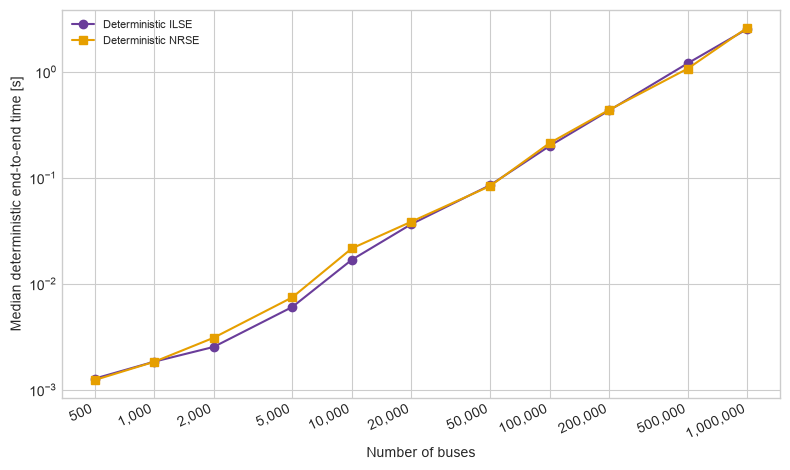

In [7]:
PLOT_SPECS = [
    ("Deterministic ILSE", "#6A3D9A", "o"),
    ("Deterministic NRSE", "#E69F00", "s"),
]

with plt.style.context("seaborn-v0_8-whitegrid"):
    figure, axis = plt.subplots(figsize=(8, 4.8))
    for method_name, color, marker in PLOT_SPECS:
        subset = timing_results[timing_results["method"] == method_name].sort_values("buses")
        axis.plot(
            subset["buses"],
            subset["median time [s]"],
            color=color,
            label=method_name,
            linestyle="-",
            marker=marker,
        )
    bus_ticks = sorted(timing_results["buses"].unique())
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Number of buses")
    axis.set_ylabel("Median deterministic end-to-end time [s]")
    axis.set_xticks(bus_ticks)
    axis.set_xticklabels(
        [f"{bus_count:,}" for bus_count in bus_ticks],
        rotation=25,
        ha="right",
    )
    axis.legend(fontsize=8)
    figure.tight_layout()
    figure.savefig(FIGURE_PATH, dpi=200)
    display(figure)
    plt.close(figure)


## Empirical fits

The power model $t=Cn^p$ summarizes multiplicative scaling on log-log axes. The affine model $t=a+bn$ separates a fixed cost from a per-bus cost. Their $R^2$ values use different response scales—log time and time—so they are not directly comparable.


In [8]:
MINIMUM_FIT_POINTS = 3
power_fit_rows = []
affine_fit_rows = []

for method_name in METHOD_SPECS:
    subset = timing_results[timing_results["method"] == method_name].sort_values("buses")
    if len(subset) < MINIMUM_FIT_POINTS:
        continue

    bus_count = subset["buses"].to_numpy(dtype=float)
    elapsed_time = subset["median time [s]"].to_numpy(dtype=float)
    log_bus_count = np.log(bus_count)
    log_time = np.log(elapsed_time)

    exponent, log_prefactor = np.polyfit(log_bus_count, log_time, deg=1)
    fitted_log_time = exponent * log_bus_count + log_prefactor
    log_residual_sum_squares = np.sum((log_time - fitted_log_time) ** 2)
    log_total_sum_squares = np.sum((log_time - np.mean(log_time)) ** 2)
    power_fit_rows.append(
        {
            "method": method_name,
            "fit range [buses]": f"{int(bus_count.min()):,}-{int(bus_count.max()):,}",
            "fit points": len(subset),
            "power exponent p": exponent,
            "power R² [log time]": 1.0 - log_residual_sum_squares / log_total_sum_squares,
            "power timing law": (f"t ≈ {np.exp(log_prefactor):.3e} * n^{exponent:.2f} s"),
        }
    )

    affine_slope, affine_intercept = np.polyfit(bus_count, elapsed_time, deg=1)
    fitted_time = affine_intercept + affine_slope * bus_count
    residual_sum_squares = np.sum((elapsed_time - fitted_time) ** 2)
    total_sum_squares = np.sum((elapsed_time - np.mean(elapsed_time)) ** 2)
    affine_fit_rows.append(
        {
            "method": method_name,
            "fit range [buses]": f"{int(bus_count.min()):,}-{int(bus_count.max()):,}",
            "fit points": len(subset),
            "affine intercept a [ms]": 1e3 * affine_intercept,
            "affine slope b [µs/bus]": 1e6 * affine_slope,
            "affine R² [time]": 1.0 - residual_sum_squares / total_sum_squares,
            "affine timing law": (f"t ≈ {1e3 * affine_intercept:.2f} ms + {1e6 * affine_slope:.3f} µs/bus * n"),
        }
    )

power_fit_table = pd.DataFrame(power_fit_rows)
affine_fit_table = pd.DataFrame(affine_fit_rows)
display(
    power_fit_table.style.set_uuid("synthetic_power_scaling")
    .set_caption("Power-law fit: t = C n^p")
    .format({"power exponent p": "{:.2f}", "power R² [log time]": "{:.3f}"})
    .hide(axis="index")
)
display(
    affine_fit_table.style.set_uuid("synthetic_affine_scaling")
    .set_caption("Affine fit: t = a + b n")
    .format(
        {
            "affine intercept a [ms]": "{:.2f}",
            "affine slope b [µs/bus]": "{:.3f}",
            "affine R² [time]": "{:.3f}",
        }
    )
    .hide(axis="index")
)

method,fit range [buses],fit points,power exponent p,power R² [log time],power timing law
Deterministic ILSE,"500-1,000,000",11,1.04,0.993,t ≈ 1.213e-06 * n^1.04 s
Deterministic NRSE,"500-1,000,000",11,1.03,0.996,t ≈ 1.501e-06 * n^1.03 s


method,fit range [buses],fit points,affine intercept a [ms],affine slope b [µs/bus],affine R² [time],affine timing law
Deterministic ILSE,"500-1,000,000",11,-22.91,2.537,0.999,t ≈ -22.91 ms + 2.537 µs/bus * n
Deterministic NRSE,"500-1,000,000",11,-28.52,2.551,0.993,t ≈ -28.52 ms + 2.551 µs/bus * n


## Interpretation

- Use each fitted exponent as an empirical summary over these eleven sizes, not as a proof of asymptotic Big-O complexity.
- The power-law fit summarizes proportional scaling, while the affine fit estimates fixed overhead and incremental time per bus.
- Compare the ILSE and NRSE timing series directly; no analytical-UQ or Monte Carlo work is included in this notebook.
- Because this topology has bounded degree, it isolates how deterministic state-estimation work grows with the total number of buses.
